In [ ]:
!pip install torch torchtext
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 9.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 10.3 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

# Load the IMDb dataset
imdb = load_dataset('imdb')

# Check the number of examples in each split
train_size = len(imdb['train'])
test_size = len(imdb['test'])

print(f"Number of training examples: {train_size}")
print(f"Number of test examples: {test_size}")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Number of training examples: 25000
Number of test examples: 25000


## DistilBERT

In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, AdamW
from transformers import get_scheduler
from torch.utils.data import DataLoader
from datasets import load_dataset
import random
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tqdm.auto import tqdm
import pandas as pd
import re

imdb = load_dataset('imdb')

print(imdb['train'][0])

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', lower = True)

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_function(examples):
    examples['text'] = [clean_text(text) for text in examples['text']]
    return tokenizer(examples['text'], padding='max_length', truncation=True)

encoded_imdb = imdb.map(preprocess_function, batched=True)

encoded_imdb = encoded_imdb.remove_columns(["text"])
encoded_imdb.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

train_dataset = encoded_imdb['train']
test_dataset = encoded_imdb['test']

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_and_evaluate(seed, num_epochs=3, lr=2e-5):
    set_seed(seed)

    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=64)

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = num_epochs * len(train_dataloader)
    lr_scheduler = get_scheduler(
        "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
    )

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        all_labels = []
        all_preds = []

        for batch in train_dataloader:
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            preds = logits.argmax(dim=-1).detach().cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

        train_acc = accuracy_score(all_labels, all_preds)
        train_precision = precision_score(all_labels, all_preds, average='binary')
        train_recall = recall_score(all_labels, all_preds, average='binary')

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")

    model.eval()
    all_test_labels = []
    all_test_preds = []
    all_test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            logits = outputs.logits
            preds = logits.argmax(dim=-1)

            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(batch['labels'].cpu().numpy())
            all_test_logits.extend(torch.softmax(logits, dim=-1).cpu().numpy())

    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_precision = precision_score(all_test_labels, all_test_preds, average='binary')
    test_recall = recall_score(all_test_labels, all_test_preds, average='binary')

    print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

    df = pd.DataFrame(all_test_logits, columns=['Negative Probability', 'Positive Probability'])
    df['True Label'] = all_test_labels
    df['Predicted Label'] = all_test_preds
    df.to_csv(f'imdb_test_predictions_seed_{seed}.csv', index=False)

seeds = [42, 43, 44, 45, 46]

for seed in seeds:
    print(f"\nTraining with seed {seed}")
    train_and_evaluate(seed)


{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


Training with seed 42


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Test Accuracy: 0.9302, Precision: 0.9217, Recall: 0.9402

Training with seed 46


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 0.2755, Accuracy: 0.8846, Precision: 0.8832, Recall: 0.8865
Epoch 2/3, Loss: 0.1588, Accuracy: 0.9416, Precision: 0.9406, Recall: 0.9426
Epoch 3/3, Loss: 0.1095, Accuracy: 0.9633, Precision: 0.9622, Recall: 0.9646


  0%|          | 0/391 [00:00<?, ?it/s]

Test Accuracy: 0.9307, Precision: 0.9263, Recall: 0.9358


## Reduce Layers of DistilBert

In [ ]:
imdb = load_dataset('imdb')

print(imdb['train'][0])

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', lower = True)

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_function(examples):
    examples['text'] = [clean_text(text) for text in examples['text']]
    return tokenizer(examples['text'], padding='max_length', truncation=True)

encoded_imdb = imdb.map(preprocess_function, batched=True)

encoded_imdb = encoded_imdb.remove_columns(["text"])
encoded_imdb.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

train_dataset = encoded_imdb['train']
test_dataset = encoded_imdb['test']

def reduce_bert_layers(model, num_layers_to_keep):
    model.distilbert.transformer.layer = torch.nn.ModuleList(
        model.distilbert.transformer.layer[:num_layers_to_keep]
    )
    return model

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_and_evaluate(seed, num_epochs=3, lr=2e-5, num_layers=6):
    set_seed(seed)

    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
    test_dataloader = DataLoader(test_dataset, batch_size=64, num_workers=4)

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

    model = reduce_bert_layers(model, num_layers)

    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = num_epochs * len(train_dataloader)
    lr_scheduler = get_scheduler(
        "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
    )

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        all_labels = []
        all_preds = []

        for batch in train_dataloader:
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            preds = logits.argmax(dim=-1).detach().cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

        train_acc = accuracy_score(all_labels, all_preds)
        train_precision = precision_score(all_labels, all_preds, average='binary')
        train_recall = recall_score(all_labels, all_preds, average='binary')

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")

    model.eval()
    all_test_labels = []
    all_test_preds = []
    all_test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            logits = outputs.logits
            preds = logits.argmax(dim=-1)

            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(batch['labels'].cpu().numpy())
            all_test_logits.extend(torch.softmax(logits, dim=-1).cpu().numpy())  # 保存二分类的概率

    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_precision = precision_score(all_test_labels, all_test_preds, average='binary')
    test_recall = recall_score(all_test_labels, all_test_preds, average='binary')

    print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

    df = pd.DataFrame(all_test_logits, columns=['Negative Probability', 'Positive Probability'])
    df['True Label'] = all_test_labels
    df['Predicted Label'] = all_test_preds
    df.to_csv(f'imdb_test_predictions_seed_{seed}_layers_{num_layers}.csv', index=False)

seeds = [42, 43, 44, 45, 46]
num_layers_list = [3]

for seed in seeds:
    for num_layers in num_layers_list:
        print(f"\nTraining with seed {seed} and {num_layers} layers")
        train_and_evaluate(seed, num_layers=num_layers)

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_war

Epoch 1/3, Loss: 0.3692, Accuracy: 0.8275, Precision: 0.8250, Recall: 0.8314
Epoch 2/3, Loss: 0.2265, Accuracy: 0.9119, Precision: 0.9122, Recall: 0.9116
Epoch 3/3, Loss: 0.1796, Accuracy: 0.9334, Precision: 0.9321, Recall: 0.9348


  0%|          | 0/391 [00:00<?, ?it/s]

Test Accuracy: 0.9087, Precision: 0.9030, Recall: 0.9157

Training with seed 43 and 3 layers


...


Training with seed 46 and 3 layers


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 0.3710, Accuracy: 0.8282, Precision: 0.8284, Recall: 0.8279
Epoch 2/3, Loss: 0.2262, Accuracy: 0.9109, Precision: 0.9103, Recall: 0.9117
Epoch 3/3, Loss: 0.1818, Accuracy: 0.9315, Precision: 0.9319, Recall: 0.9310


  0%|          | 0/391 [00:00<?, ?it/s]

Test Accuracy: 0.9088, Precision: 0.9050, Recall: 0.9135


## Delete Attention heads of DistilBert

In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, AdamW
from transformers import get_scheduler
from torch.utils.data import DataLoader
from datasets import load_dataset
import random
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tqdm.auto import tqdm
import pandas as pd
import re

imdb = load_dataset('imdb')

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', lower=True)

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_function(examples):
    examples['text'] = [clean_text(text) for text in examples['text']]
    return tokenizer(examples['text'], padding='max_length', truncation=True)

encoded_imdb = imdb.map(preprocess_function, batched=True)

encoded_imdb = encoded_imdb.remove_columns(["text"])
encoded_imdb.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

train_dataset = encoded_imdb['train']
test_dataset = encoded_imdb['test']

def remove_attention_layers(model):
    for layer in model.distilbert.transformer.layer:
        layer.attention.q_lin = torch.nn.Identity()
        layer.attention.k_lin = torch.nn.Identity()
        layer.attention.v_lin = torch.nn.Identity()
        layer.attention.out_lin = torch.nn.Identity()
    return model

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_and_evaluate(seed, num_epochs=3, lr=2e-5):
    set_seed(seed)

    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
    test_dataloader = DataLoader(test_dataset, batch_size=64, num_workers=4)

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

    model = remove_attention_layers(model)

    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = num_epochs * len(train_dataloader)
    lr_scheduler = get_scheduler(
        "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
    )

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        all_labels = []
        all_preds = []

        for batch in train_dataloader:
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            preds = logits.argmax(dim=-1).detach().cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

        train_acc = accuracy_score(all_labels, all_preds)
        train_precision = precision_score(all_labels, all_preds, average='binary')
        train_recall = recall_score(all_labels, all_preds, average='binary')

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")

    model.eval()
    all_test_labels = []
    all_test_preds = []
    all_test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            logits = outputs.logits
            preds = logits.argmax(dim=-1)

            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(batch['labels'].cpu().numpy())
            all_test_logits.extend(torch.softmax(logits, dim=-1).cpu().numpy())

    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_precision = precision_score(all_test_labels, all_test_preds, average='binary')
    test_recall = recall_score(all_test_labels, all_test_preds, average='binary')

    print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

    df = pd.DataFrame(all_test_logits, columns=['Negative Probability', 'Positive Probability'])
    df['True Label'] = all_test_labels
    df['Predicted Label'] = all_test_preds
    df.to_csv(f'imdb_test_predictions_seed_{seed}_no_attention.csv', index=False)

seeds = [42, 43, 44, 45, 46]

for seed in seeds:
    print(f"\nTraining with seed {seed} without attention mechanism")
    train_and_evaluate(seed)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



Training with seed 42 without attention mechanism


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 0.4837, Accuracy: 0.7494, Precision: 0.7463, Recall: 0.7558
Epoch 2/3, Loss: 0.2915, Accuracy: 0.8798, Precision: 0.8791, Recall: 0.8809
Epoch 3/3, Loss: 0.2460, Accuracy: 0.9040, Precision: 0.9031, Recall: 0.9052


  0%|          | 0/391 [00:00<?, ?it/s]

...

Test Accuracy: 0.8718, Precision: 0.8703, Recall: 0.8738

Training with seed 46 without attention mechanism


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 0.4952, Accuracy: 0.7376, Precision: 0.7250, Recall: 0.7656
Epoch 2/3, Loss: 0.3087, Accuracy: 0.8710, Precision: 0.8686, Recall: 0.8743
Epoch 3/3, Loss: 0.2654, Accuracy: 0.8922, Precision: 0.8920, Recall: 0.8924


  0%|          | 0/391 [00:00<?, ?it/s]

Test Accuracy: 0.8707, Precision: 0.8552, Recall: 0.8926


##  Delete Feed-forward connection layer for DistilBert

In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, AdamW
from transformers import get_scheduler
from torch.utils.data import DataLoader
from datasets import load_dataset
import random
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tqdm.auto import tqdm
import pandas as pd
import re

imdb = load_dataset('imdb')

print(imdb['train'][0])

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', lower=True)

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_function(examples):
    examples['text'] = [clean_text(text) for text in examples['text']]
    return tokenizer(examples['text'], padding='max_length', truncation=True)

encoded_imdb = imdb.map(preprocess_function, batched=True)

encoded_imdb = encoded_imdb.remove_columns(["text"])
encoded_imdb.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

train_dataset = encoded_imdb['train']
test_dataset = encoded_imdb['test']

def remove_feedforward_layers(model):
    for layer in model.distilbert.transformer.layer:
        layer.ffn = torch.nn.Identity()
    return model

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_and_evaluate(seed, num_epochs=3, lr=2e-5):
    set_seed(seed)

    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
    test_dataloader = DataLoader(test_dataset, batch_size=64, num_workers=4)

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

    model = remove_feedforward_layers(model)

    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = num_epochs * len(train_dataloader)
    lr_scheduler = get_scheduler(
        "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
    )

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        all_labels = []
        all_preds = []

        for batch in train_dataloader:
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            preds = logits.argmax(dim=-1).detach().cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

        train_acc = accuracy_score(all_labels, all_preds)
        train_precision = precision_score(all_labels, all_preds, average='binary')
        train_recall = recall_score(all_labels, all_preds, average='binary')

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")

    model.eval()
    all_test_labels = []
    all_test_preds = []
    all_test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            logits = outputs.logits
            preds = logits.argmax(dim=-1)

            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(batch['labels'].cpu().numpy())
            all_test_logits.extend(torch.softmax(logits, dim=-1).cpu().numpy())  # 保存二分类的概率

    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_precision = precision_score(all_test_labels, all_test_preds, average='binary')
    test_recall = recall_score(all_test_labels, all_test_preds, average='binary')

    print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

    df = pd.DataFrame(all_test_logits, columns=['Negative Probability', 'Positive Probability'])
    df['True Label'] = all_test_labels
    df['Predicted Label'] = all_test_preds
    df.to_csv(f'imdb_test_predictions_seed_{seed}_no_ffn.csv', index=False)


seeds = [42, 43, 44, 45, 46]

for seed in seeds:
    print(f"\nTraining with seed {seed}, no feedforward layers")
    train_and_evaluate(seed)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 0.3861, Accuracy: 0.8219, Precision: 0.8244, Recall: 0.8179
Epoch 2/3, Loss: 0.2490, Accuracy: 0.9006, Precision: 0.9009, Recall: 0.9002
Epoch 3/3, Loss: 0.2054, Accuracy: 0.9236, Precision: 0.9235, Recall: 0.9237


  0%|          | 0/391 [00:00<?, ?it/s]

...

Test Accuracy: 0.8982, Precision: 0.9022, Recall: 0.8933

Training with seed 46, no feedforward layers


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 0.3821, Accuracy: 0.8224, Precision: 0.8229, Recall: 0.8216
Epoch 2/3, Loss: 0.2452, Accuracy: 0.9015, Precision: 0.9005, Recall: 0.9028
Epoch 3/3, Loss: 0.2020, Accuracy: 0.9218, Precision: 0.9229, Recall: 0.9205


  0%|          | 0/391 [00:00<?, ?it/s]

Test Accuracy: 0.8999, Precision: 0.9054, Recall: 0.8931


## Delete Norm Layer

In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, AdamW
from transformers import get_scheduler
from torch.utils.data import DataLoader
from datasets import load_dataset
import random
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tqdm.auto import tqdm
import pandas as pd
import re

imdb = load_dataset('imdb')

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', lower=True)

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_function(examples):
    examples['text'] = [clean_text(text) for text in examples['text']]
    return tokenizer(examples['text'], padding='max_length', truncation=True)

encoded_imdb = imdb.map(preprocess_function, batched=True)

encoded_imdb = encoded_imdb.remove_columns(["text"])
encoded_imdb.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

train_dataset = encoded_imdb['train']
test_dataset = encoded_imdb['test']

def remove_layer_norm(model):
    for layer in model.distilbert.transformer.layer:
        layer.sa_layer_norm = torch.nn.Identity()
        layer.output_layer_norm = torch.nn.Identity()
    return model

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_and_evaluate(seed, num_epochs=3, lr=2e-5):
    set_seed(seed)

    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
    test_dataloader = DataLoader(test_dataset, batch_size=64, num_workers=4)

    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

    model = remove_layer_norm(model)

    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = num_epochs * len(train_dataloader)
    lr_scheduler = get_scheduler(
        "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
    )

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        all_labels = []
        all_preds = []

        for batch in train_dataloader:
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            preds = logits.argmax(dim=-1).detach().cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

        train_acc = accuracy_score(all_labels, all_preds)
        train_precision = precision_score(all_labels, all_preds, average='binary')
        train_recall = recall_score(all_labels, all_preds, average='binary')

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")

    model.eval()
    all_test_labels = []
    all_test_preds = []
    all_test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            batch = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)
            }

            outputs = model(**batch)
            logits = outputs.logits
            preds = logits.argmax(dim=-1)

            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(batch['labels'].cpu().numpy())
            all_test_logits.extend(torch.softmax(logits, dim=-1).cpu().numpy())

    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_precision = precision_score(all_test_labels, all_test_preds, average='binary')
    test_recall = recall_score(all_test_labels, all_test_preds, average='binary')

    print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

    df = pd.DataFrame(all_test_logits, columns=['Negative Probability', 'Positive Probability'])
    df['True Label'] = all_test_labels
    df['Predicted Label'] = all_test_preds
    df.to_csv(f'imdb_test_predictions_seed_{seed}_no_layernorm.csv', index=False)

seeds = [42, 43, 44, 45, 46]

for seed in seeds:
    print(f"\nTraining with seed {seed} and no LayerNorm")
    train_and_evaluate(seed)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Test Accuracy: 0.5049, Precision: 0.5025, Recall: 0.9654

Training with seed 46 and no LayerNorm


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Loss: 403.1918, Accuracy: 0.5136, Precision: 0.5138, Recall: 0.5057
Epoch 2/3, Loss: 494.0004, Accuracy: 0.5082, Precision: 0.5083, Recall: 0.5046
Epoch 3/3, Loss: 506.1147, Accuracy: 0.5019, Precision: 0.5019, Recall: 0.4954


  0%|          | 0/391 [00:00<?, ?it/s]

Test Accuracy: 0.5004, Precision: 0.5003, Recall: 0.7099


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import pandas as pd

file_path1 = '/content/imdb_test_predictions_seed_42.csv'
df1 = pd.read_csv(file_path1)
file_path2 = '/content/imdb_test_predictions_seed_42_no_layernorm.csv'
df2 = pd.read_csv(file_path2)

def ll(x, p):
        z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
        return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]


def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))


def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    #print(ll_basic)
    ll_enhanced = ll(y, y_enhanced)
    #print(ll_enhanced)
    w0 = get_w(ll_basic)
    #print(w0)
    w1 = get_w(ll_enhanced)
    #print(w1)
    return (w1 - w0) / w0

y = df1['True Label'].values
y_enhanced = df1['Positive Probability'].values
y_basic = df2['Positive Probability'].values

calculate_imv(y_basic, y_enhanced, y)

0.9025130115096172

## Ablate-IMV and Viz

### Calcualte the Ablate-IMV Confusion Matrix for the NLP task

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
def ll(x, p):
        z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
        return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]


def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))


def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    #print(ll_basic)
    ll_enhanced = ll(y, y_enhanced)
    #print(ll_enhanced)
    w0 = get_w(ll_basic)
    #print(w0)
    w1 = get_w(ll_enhanced)
    #print(w1)
    return (w1 - w0) / w0


df1 = pd.read_csv('/content/imdb_test_predictions_seed_42.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_42_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_42_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_42_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_42_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}

y = df1['True Label'].values

model_names = list(preds.keys())
imv_matrix_1 = pd.DataFrame(np.zeros((len(model_names), len(model_names))), columns=model_names, index=model_names)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        if i == j:
            continue

        #print(f"Comparing {model_names[i]} and {model_names[j]}")

        if model_names[i] == 'Original':
            y_basic = preds[model_names[j]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[j]}, y_enhanced = Original")
        elif model_names[j] == 'Original':
            y_basic = preds[model_names[i]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[i]}, y_enhanced = Original")
        else:
            y_basic = preds[model_names[i]]
            y_enhanced = preds[model_names[j]]
            #print(f"y_basic = {model_names[i]}, y_enhanced = {model_names[j]}")

        imv_value = calculate_imv(y_basic, y_enhanced, y)
        #print(f"IMV({model_names[i]}, {model_names[j]}) = {imv_value}\n")


        imv_matrix_1.iloc[i, j] = imv_value
print(imv_matrix_1)

df1 = pd.read_csv('/content/imdb_test_predictions_seed_43.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_43_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_43_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_43_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_43_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}

y = df1['True Label'].values

model_names = list(preds.keys())
imv_matrix_2 = pd.DataFrame(np.zeros((len(model_names), len(model_names))), columns=model_names, index=model_names)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        if i == j:
            continue

        #print(f"Comparing {model_names[i]} and {model_names[j]}")

        if model_names[i] == 'Original':
            y_basic = preds[model_names[j]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[j]}, y_enhanced = Original")
        elif model_names[j] == 'Original':
            y_basic = preds[model_names[i]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[i]}, y_enhanced = Original")
        else:
            y_basic = preds[model_names[i]]
            y_enhanced = preds[model_names[j]]
            #print(f"y_basic = {model_names[i]}, y_enhanced = {model_names[j]}")

        imv_value = calculate_imv(y_basic, y_enhanced, y)
        #print(f"IMV({model_names[i]}, {model_names[j]}) = {imv_value}\n")


        imv_matrix_2.iloc[i, j] = imv_value
print(imv_matrix_2)


df1 = pd.read_csv('/content/imdb_test_predictions_seed_44.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_44_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_44_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_44_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_44_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}

y = df1['True Label'].values


model_names = list(preds.keys())
imv_matrix_3 = pd.DataFrame(np.zeros((len(model_names), len(model_names))), columns=model_names, index=model_names)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        if i == j:
            continue

        #print(f"Comparing {model_names[i]} and {model_names[j]}")

        if model_names[i] == 'Original':
            y_basic = preds[model_names[j]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[j]}, y_enhanced = Original")
        elif model_names[j] == 'Original':
            y_basic = preds[model_names[i]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[i]}, y_enhanced = Original")
        else:
            y_basic = preds[model_names[i]]
            y_enhanced = preds[model_names[j]]
            #print(f"y_basic = {model_names[i]}, y_enhanced = {model_names[j]}")

        imv_value = calculate_imv(y_basic, y_enhanced, y)
        #print(f"IMV({model_names[i]}, {model_names[j]}) = {imv_value}\n")


        imv_matrix_3.iloc[i, j] = imv_value
print(imv_matrix_3)

df1 = pd.read_csv('/content/imdb_test_predictions_seed_45.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_45_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_45_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_45_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_45_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}

y = df1['True Label'].values

model_names = list(preds.keys())
imv_matrix_4 = pd.DataFrame(np.zeros((len(model_names), len(model_names))), columns=model_names, index=model_names)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        if i == j:
            continue

        #print(f"Comparing {model_names[i]} and {model_names[j]}")

        if model_names[i] == 'Original':
            y_basic = preds[model_names[j]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[j]}, y_enhanced = Original")
        elif model_names[j] == 'Original':
            y_basic = preds[model_names[i]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[i]}, y_enhanced = Original")
        else:
            y_basic = preds[model_names[i]]
            y_enhanced = preds[model_names[j]]
            #print(f"y_basic = {model_names[i]}, y_enhanced = {model_names[j]}")

        imv_value = calculate_imv(y_basic, y_enhanced, y)
        #print(f"IMV({model_names[i]}, {model_names[j]}) = {imv_value}\n")


        imv_matrix_4.iloc[i, j] = imv_value
print(imv_matrix_4)


df1 = pd.read_csv('/content/imdb_test_predictions_seed_46.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_46_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_46_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_46_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_46_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}

y = df1['True Label'].values

model_names = list(preds.keys())
imv_matrix_5 = pd.DataFrame(np.zeros((len(model_names), len(model_names))), columns=model_names, index=model_names)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        if i == j:
            continue

        #print(f"Comparing {model_names[i]} and {model_names[j]}")

        if model_names[i] == 'Original':
            y_basic = preds[model_names[j]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[j]}, y_enhanced = Original")
        elif model_names[j] == 'Original':
            y_basic = preds[model_names[i]]
            y_enhanced = preds['Original']
            #print(f"y_basic = {model_names[i]}, y_enhanced = Original")
        else:
            y_basic = preds[model_names[i]]
            y_enhanced = preds[model_names[j]]
            #print(f"y_basic = {model_names[i]}, y_enhanced = {model_names[j]}")

        imv_value = calculate_imv(y_basic, y_enhanced, y)
        #print(f"IMV({model_names[i]}, {model_names[j]}) = {imv_value}\n")


        imv_matrix_5.iloc[i, j] = imv_value
print(imv_matrix_5)

imv_matrices = [imv_matrix_1, imv_matrix_2, imv_matrix_3, imv_matrix_4, imv_matrix_5]
imv_mean_matrix = sum(imv_matrices) / len(imv_matrices)
print(imv_mean_matrix)

             Original   3Layers  NoAttention     NoFFN    NoNorm
Original     0.000000  0.016162     0.058121  0.022762  0.902513
3Layers      0.016162  0.000000    -0.039654 -0.006453 -0.465884
NoAttention  0.058121  0.041291     0.000000  0.034572 -0.443830
NoFFN        0.022762  0.006495    -0.033417  0.000000 -0.462415
NoNorm       0.902513  0.872254     0.798012  0.860172  0.000000
             Original   3Layers  NoAttention     NoFFN    NoNorm
Original     0.000000  0.014485     0.055825  0.022787  0.901512
3Layers      0.014485  0.000000    -0.039155 -0.008117 -0.466485
NoAttention  0.055825  0.040750     0.000000  0.032302 -0.444745
NoFFN        0.022787  0.008184    -0.031291  0.000000 -0.462119
NoNorm       0.901512  0.874363     0.800973  0.859148  0.000000
             Original   3Layers  NoAttention     NoFFN    NoNorm
Original     0.000000  0.014306     0.052178  0.020113  0.899798
3Layers      0.014306  0.000000    -0.035994 -0.005692 -0.466098
NoAttention  0.052178  0.

### Calcualte the IMV for the NLP task

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
def ll(x, p):
        z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
        return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]


def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))


def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    #print(ll_basic)
    ll_enhanced = ll(y, y_enhanced)
    #print(ll_enhanced)
    w0 = get_w(ll_basic)
    #print(w0)
    w1 = get_w(ll_enhanced)
    #print(w1)
    return (w1 - w0) / w0

df1 = pd.read_csv('/content/imdb_test_predictions_seed_42.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_42_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_42_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_42_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_42_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}
y = df1['True Label'].values
y_basic = np.full_like(df1['True Label'].values, 0.5, dtype=float)

imv_values = {}

for model_name, y_enhanced in preds.items():
    imv_value = calculate_imv(y_basic, y_enhanced, y)
    imv_values[model_name] = imv_value
print(imv_values)


df1 = pd.read_csv('/content/imdb_test_predictions_seed_43.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_43_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_43_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_43_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_43_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}
y = df1['True Label'].values
y_basic = np.full_like(df1['True Label'].values, 0.5, dtype=float)

imv_values = {}

for model_name, y_enhanced in preds.items():
    imv_value = calculate_imv(y_basic, y_enhanced, y)
    imv_values[model_name] = imv_value
print(imv_values)


df1 = pd.read_csv('/content/imdb_test_predictions_seed_44.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_44_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_44_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_44_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_44_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}
y = df1['True Label'].values
y_basic = np.full_like(df1['True Label'].values, 0.5, dtype=float)

imv_values = {}

for model_name, y_enhanced in preds.items():
    imv_value = calculate_imv(y_basic, y_enhanced, y)
    imv_values[model_name] = imv_value
print(imv_values)

df1 = pd.read_csv('/content/imdb_test_predictions_seed_45.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_45_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_45_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_45_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_45_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}
y = df1['True Label'].values
y_basic = np.full_like(df1['True Label'].values, 0.5, dtype=float)

imv_values = {}

for model_name, y_enhanced in preds.items():
    imv_value = calculate_imv(y_basic, y_enhanced, y)
    imv_values[model_name] = imv_value
print(imv_values)

df1 = pd.read_csv('/content/imdb_test_predictions_seed_46.csv')
df2 = pd.read_csv('/content/imdb_test_predictions_seed_46_layers_3.csv')
df3 = pd.read_csv('/content/imdb_test_predictions_seed_46_no_attention.csv')
df4 = pd.read_csv('/content/imdb_test_predictions_seed_46_no_ffn.csv')
df5 = pd.read_csv('/content/imdb_test_predictions_seed_46_no_layernorm.csv')

preds = {
    'Original': df1['Positive Probability'].values,
    '3Layers': df2['Positive Probability'].values,
    'NoAttention': df3['Positive Probability'].values,
    'NoFFN': df4['Positive Probability'].values,
    'NoNorm': df5['Positive Probability'].values
}
y = df1['True Label'].values
y_basic = np.full_like(df1['True Label'].values, 0.5, dtype=float)

imv_values = {}

for model_name, y_enhanced in preds.items():
    imv_value = calculate_imv(y_basic, y_enhanced, y)
    imv_values[model_name] = imv_value
print(imv_values)

{'Original': 0.9023926946003278, '3Layers': 0.8721352908448358, 'NoAttention': 0.7978979329468248, 'NoFFN': 0.8600547484418348, 'NoNorm': -6.324104411457285e-05}
{'Original': 0.9013922426532409, '3Layers': 0.874244573966427, 'NoAttention': 0.8008591141826727, 'NoFFN': 0.8590304743729369, 'NoNorm': -6.324104411457285e-05}
{'Original': 0.8996776243463505, '3Layers': 0.872883982371709, 'NoAttention': 0.8054722458519088, 'NoFFN': 0.8622231669326323, 'NoNorm': -6.324104411457285e-05}
{'Original': 0.9011831311259096, '3Layers': 0.8739733670011058, 'NoAttention': 0.8123290441120601, 'NoFFN': 0.8627557717313964, 'NoNorm': -6.324104411457285e-05}
{'Original': 0.9024773750328619, '3Layers': 0.8751406487589303, 'NoAttention': 0.8081508598279975, 'NoFFN': 0.8621269743650268, 'NoNorm': -6.324104411457285e-05}


### Viz Ablate-IMV for NLP task

<ipython-input-11-cce01ba99afb>:55: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(mean_values.index, rotation=45, fontsize=14, family='serif')


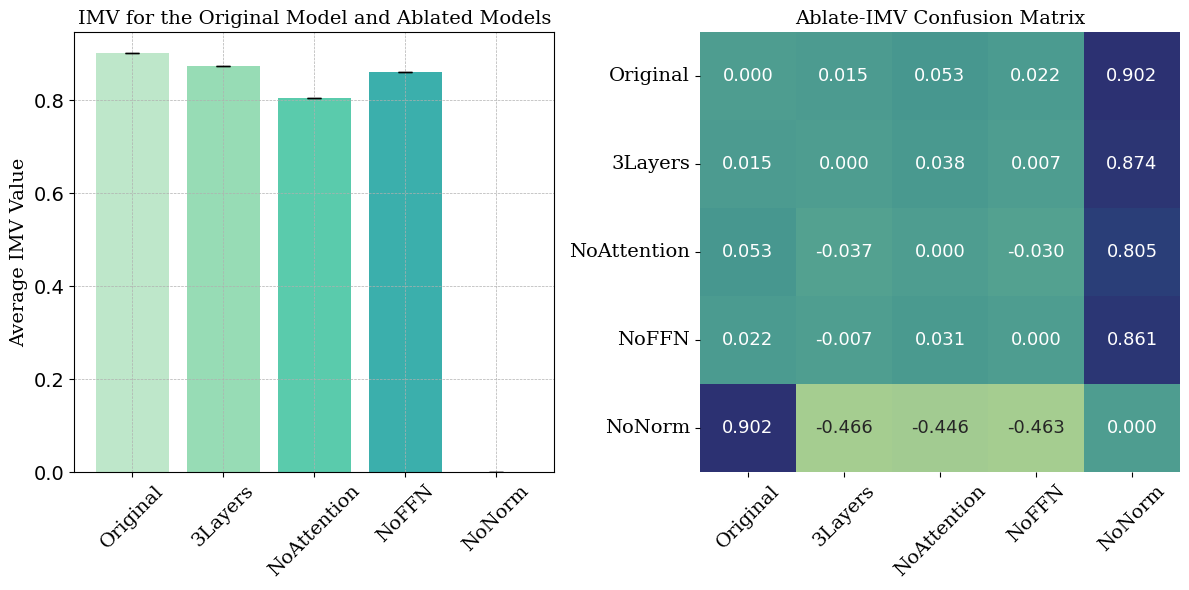

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the data for the bar plot
data_bar = [
    {'Original': 0.9023926946003278, '3Layers': 0.8721352908448358, 'NoAttention': 0.7978979329468248, 'NoFFN': 0.8600547484418348, 'NoNorm': 0.0},
    {'Original': 0.9013922426532409, '3Layers': 0.874244573966427, 'NoAttention': 0.8008591141826727, 'NoFFN': 0.8590304743729369, 'NoNorm': 0.0},
    {'Original': 0.8996776243463505, '3Layers': 0.872883982371709, 'NoAttention': 0.8054722458519088, 'NoFFN': 0.8622231669326323, 'NoNorm': 0.0},
    {'Original': 0.9011831311259096, '3Layers': 0.8739733670011058, 'NoAttention': 0.8123290441120601, 'NoFFN': 0.8627557717313964, 'NoNorm': 0.0},
    {'Original': 0.9024773750328619, '3Layers': 0.8751406487589303, 'NoAttention': 0.8081508598279975, 'NoFFN': 0.8621269743650268, 'NoNorm': 0.0}
]

# Create DataFrame for bar plot
df_bar = pd.DataFrame(data_bar)

# Calculate mean and standard deviation
mean_values = df_bar.mean()
std_values = df_bar.var()

# Colors
hex_colors = ['#bee7ca', '#97dcb5', '#5acbac', '#3bafac', '#3499a9', '#3487a5', '#3570a0', '#3d4e93', '#404589']

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))

colors = [hex_to_rgb(hex_color) for hex_color in hex_colors[:len(mean_values)]]

# Data for heatmap
data_heatmap = pd.DataFrame({
    1: [0.000000, 0.014810, 0.053464, 0.021592, 0.901545],
    2: [0.014810, 0.000000, -0.036684, -0.006638, -0.466323],
    3: [0.053464, 0.038088, 0.000000, 0.031196, -0.445996],
    4: [0.021592, 0.006683, -0.030248, 0.000000, -0.462757],
    5: [0.901545, 0.873794, 0.805056, 0.861356, 0.000000]
}, index=[1, 2, 3, 4, 5])

# Plot configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 14,
}
x_font = {'family': 'serif', 'size': 14}

# Create a figure with 1x2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# First subplot (Bar plot)
axes[0].bar(mean_values.index, mean_values.values, yerr=std_values.values, capsize=5, color=colors)
axes[0].set_title('IMV for the Original Model and Ablated Models', fontsize=14, fontweight='normal', family='serif')
axes[0].set_xticklabels(mean_values.index, rotation=45, fontsize=14, family='serif')
axes[0].tick_params(axis='y', labelsize=14)
axes[0].set_ylabel('Average IMV Value', fontsize=14, family='serif')
axes[0].grid(True, linestyle='--', linewidth=0.5)

# Second subplot (Heatmap)
font_size = 13
sns.heatmap(data_heatmap, ax=axes[1], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
axes[1].set_title("Ablate-IMV Confusion Matrix", fontdict=font)
axes[1].set_xticklabels(['Original', '3Layers', 'NoAttention', 'NoFFN', 'NoNorm'], rotation=45, fontdict=x_font)
axes[1].set_yticklabels(['Original', '3Layers', 'NoAttention', 'NoFFN', 'NoNorm'], rotation=0, fontdict=x_font)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


### Viz Ablate-IMV for CV task

<ipython-input-13-69a371cc71d0>:55: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(mean_values.index, rotation=45, fontsize=14, family='serif')


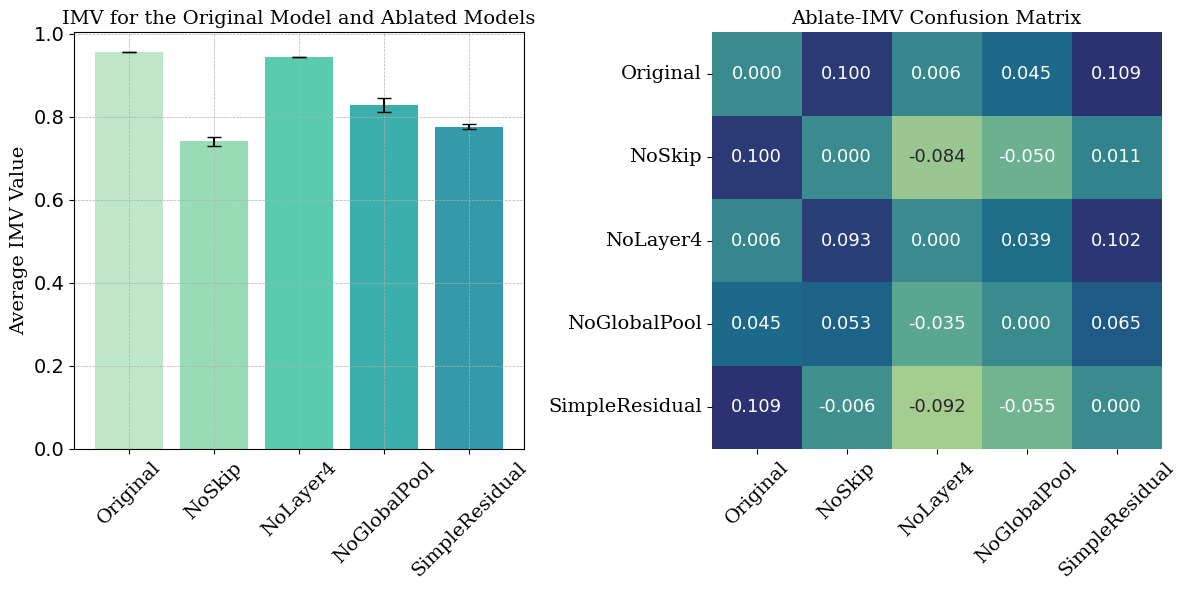

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the data for the bar plot
data_bar = [
    {'Original': 0.9772619340612636, 'NoSkip': 0.815880607487768, 'NoLayer4': 0.9587239462059752, 'NoGlobalPool': 0.915762815148269, 'SimpleResidual': 0.7392644285499804},
    {'Original': 0.9345743673154772, 'NoSkip': 0.7925258612018244, 'NoLayer4': 0.9307362017166891, 'NoGlobalPool': 0.9365317680935462, 'SimpleResidual': 0.8125792044955157},
    {'Original': 0.9617205218536187, 'NoSkip': 0.6322172557464952, 'NoLayer4': 0.9456502505859958, 'NoGlobalPool': 0.6892719911621625, 'SimpleResidual': 0.8336288498068853},
    {'Original': 0.9617205218536187, 'NoSkip': 0.6322172557464952, 'NoLayer4': 0.9456502505859958, 'NoGlobalPool': 0.6892719911621625, 'SimpleResidual': 0.8336288498068853},
    {'Original': 0.9442929998738893, 'NoSkip': 0.8331210806997887, 'NoLayer4': 0.938920131487825, 'NoGlobalPool': 0.9111677499717569, 'SimpleResidual': 0.6636491146775965}
]

# Create DataFrame for bar plot
df_bar = pd.DataFrame(data_bar)

# Calculate mean and standard deviation
mean_values = df_bar.mean()
std_values = df_bar.var()

# Colors
hex_colors = ['#bee7ca', '#97dcb5', '#5acbac', '#3bafac', '#3499a9', '#3487a5', '#3570a0', '#3d4e93', '#404589']

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))

colors = [hex_to_rgb(hex_color) for hex_color in hex_colors[:len(mean_values)]]

# Data for heatmap
data_heatmap = pd.DataFrame({
    1: [0.000000, 0.099819, 0.005861, 0.045167, 0.108672],
    2: [0.099819, 0.000000, 0.093347, 0.052874, -0.005865],
    3: [0.005861, -0.083572, 0.000000, -0.034836, -0.091611],
    4: [0.045167, -0.050017, 0.038994, 0.000000, -0.055400],
    5: [0.108672, 0.011032, 0.102227, 0.064623, 0.000000]
}, index=[1, 2, 3, 4, 5])

# Plot configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 14,
}
x_font = {'family': 'serif', 'size': 14}

# Create a figure with 1x2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# First subplot (Bar plot)
axes[0].bar(mean_values.index, mean_values.values, yerr=std_values.values, capsize=5, color=colors)
axes[0].set_title('IMV for the Original Model and Ablated Models', fontsize=14, fontweight='normal', family='serif')
axes[0].set_xticklabels(mean_values.index, rotation=45, fontsize=14, family='serif')
axes[0].tick_params(axis='y', labelsize=14)
axes[0].set_ylabel('Average IMV Value', fontsize=14, family='serif')
axes[0].grid(True, linestyle='--', linewidth=0.5)

# Second subplot (Heatmap)
font_size = 13
sns.heatmap(data_heatmap, ax=axes[1], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
axes[1].set_title("Ablate-IMV Confusion Matrix", fontdict=font)
axes[1].set_xticklabels(['Original', 'NoSkip', 'NoLayer4', 'NoGlobalPool', 'SimpleResidual'], rotation=45, fontdict=x_font)
axes[1].set_yticklabels(['Original', 'NoSkip', 'NoLayer4', 'NoGlobalPool', 'SimpleResidual'], rotation=0, fontdict=x_font)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

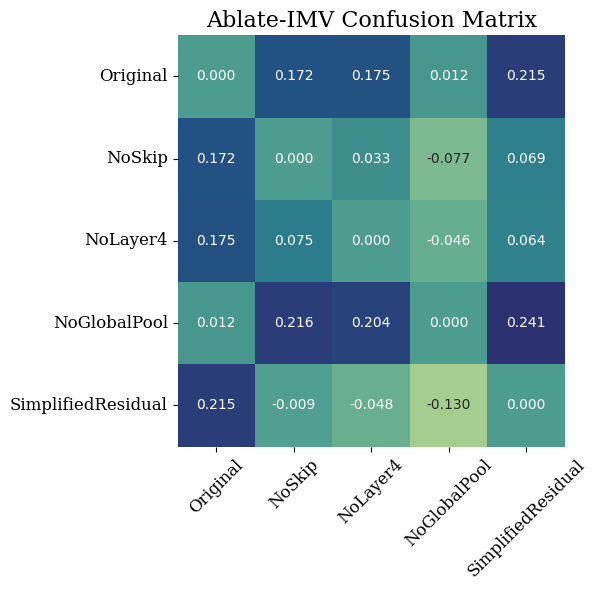

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
data = pd.DataFrame({
    1: [0.000000, 0.171797, 0.174788, 0.012179, 0.215162],
    2: [0.171797, 0.000000, 0.075431, 0.215671, -0.009016],
    3: [0.174788, 0.032785, 0.000000, 0.204404, -0.048280],
    4: [0.012179, -0.076908, -0.045530, 0.000000, -0.129977],
    5: [0.215162, 0.069172, 0.063644, 0.240791, 0.000000]
}, index=[1, 2, 3, 4, 5])

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
x_font = {'family': 'serif', 'size': 12}

# Create a single heatmap plot
fig, ax = plt.subplots(figsize=(6, 6))

# Define the font size
font_size = 10

# First heatmap (Nursery) with 5 decimal places and larger text
sns.heatmap(data, ax=ax, annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax.set_title("Ablate-IMV Confusion Matrix", fontdict=font)
ax.set_xticklabels(['Original', 'NoSkip', 'NoLayer4', 'NoGlobalPool', 'SimplifiedResidual'], rotation=45, fontdict=x_font)
ax.set_yticklabels(['Original', 'NoSkip', 'NoLayer4', 'NoGlobalPool', 'SimplifiedResidual'], rotation=0, fontdict=x_font)

# Show the plot
plt.tight_layout()
plt.show()